In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Dataset load karo
df = pd.read_csv('../data/Mental Health Dataset.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (292364, 17)

Columns:
 ['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']

Missing values:
 Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

First 5 rows:


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [3]:
# ============================================
# STEP 2: DATA CLEANING
# ============================================

# self_employed ki missing values fill karo
df['self_employed'] = df['self_employed'].fillna('Unknown')

# Timestamp ko datetime banao
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Cleaned data save karo
df.to_csv('../data/cleaned_mental_health.csv', index=False)

print("✅ Data cleaned successfully!")
print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:\n", df.isnull().sum())

✅ Data cleaned successfully!
Shape after cleaning: (292364, 17)

Missing values after cleaning:
 Timestamp                  0
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64


In [4]:
# ============================================
# STEP 3: BUSINESS INSIGHTS
# ============================================

print("=" * 50)
print("INSIGHT 1: Treatment Rate")
print("=" * 50)
treatment = df['treatment'].value_counts(normalize=True) * 100
print(treatment)

print("\n" + "=" * 50)
print("INSIGHT 2: Gender Distribution")
print("=" * 50)
gender = df['Gender'].value_counts()
print(gender)

print("\n" + "=" * 50)
print("INSIGHT 3: Occupation vs Treatment")
print("=" * 50)
occ_treatment = df.groupby('Occupation')['treatment'].value_counts(normalize=True).unstack() * 100
print(occ_treatment)

print("\n" + "=" * 50)
print("INSIGHT 4: Family History Impact")
print("=" * 50)
family = df.groupby('family_history')['treatment'].value_counts(normalize=True).unstack() * 100
print(family)

print("\n" + "=" * 50)
print("INSIGHT 5: Growing Stress by Occupation")
print("=" * 50)
stress = df.groupby('Occupation')['Growing_Stress'].value_counts(normalize=True).unstack() * 100
print(stress)

INSIGHT 1: Treatment Rate
treatment
Yes    50.487064
No     49.512936
Name: proportion, dtype: float64

INSIGHT 2: Gender Distribution
Gender
Male      239850
Female     52514
Name: count, dtype: int64

INSIGHT 3: Occupation vs Treatment
treatment          No        Yes
Occupation                      
Business    49.259208  50.740792
Corporate   50.283362  49.716638
Housewife   49.617941  50.382059
Others      49.113378  50.886622
Student     49.184387  50.815613

INSIGHT 4: Family History Impact
treatment              No        Yes
family_history                      
No              64.335641  35.664359
Yes             26.825468  73.174532

INSIGHT 5: Growing Stress by Occupation
Growing_Stress      Maybe         No        Yes
Occupation                                     
Business        33.996690  28.347524  37.655786
Corporate       27.844649  33.080730  39.074622
Housewife       36.422963  34.037166  29.539871
Others          34.821445  35.985314  29.193240
Student         37.7

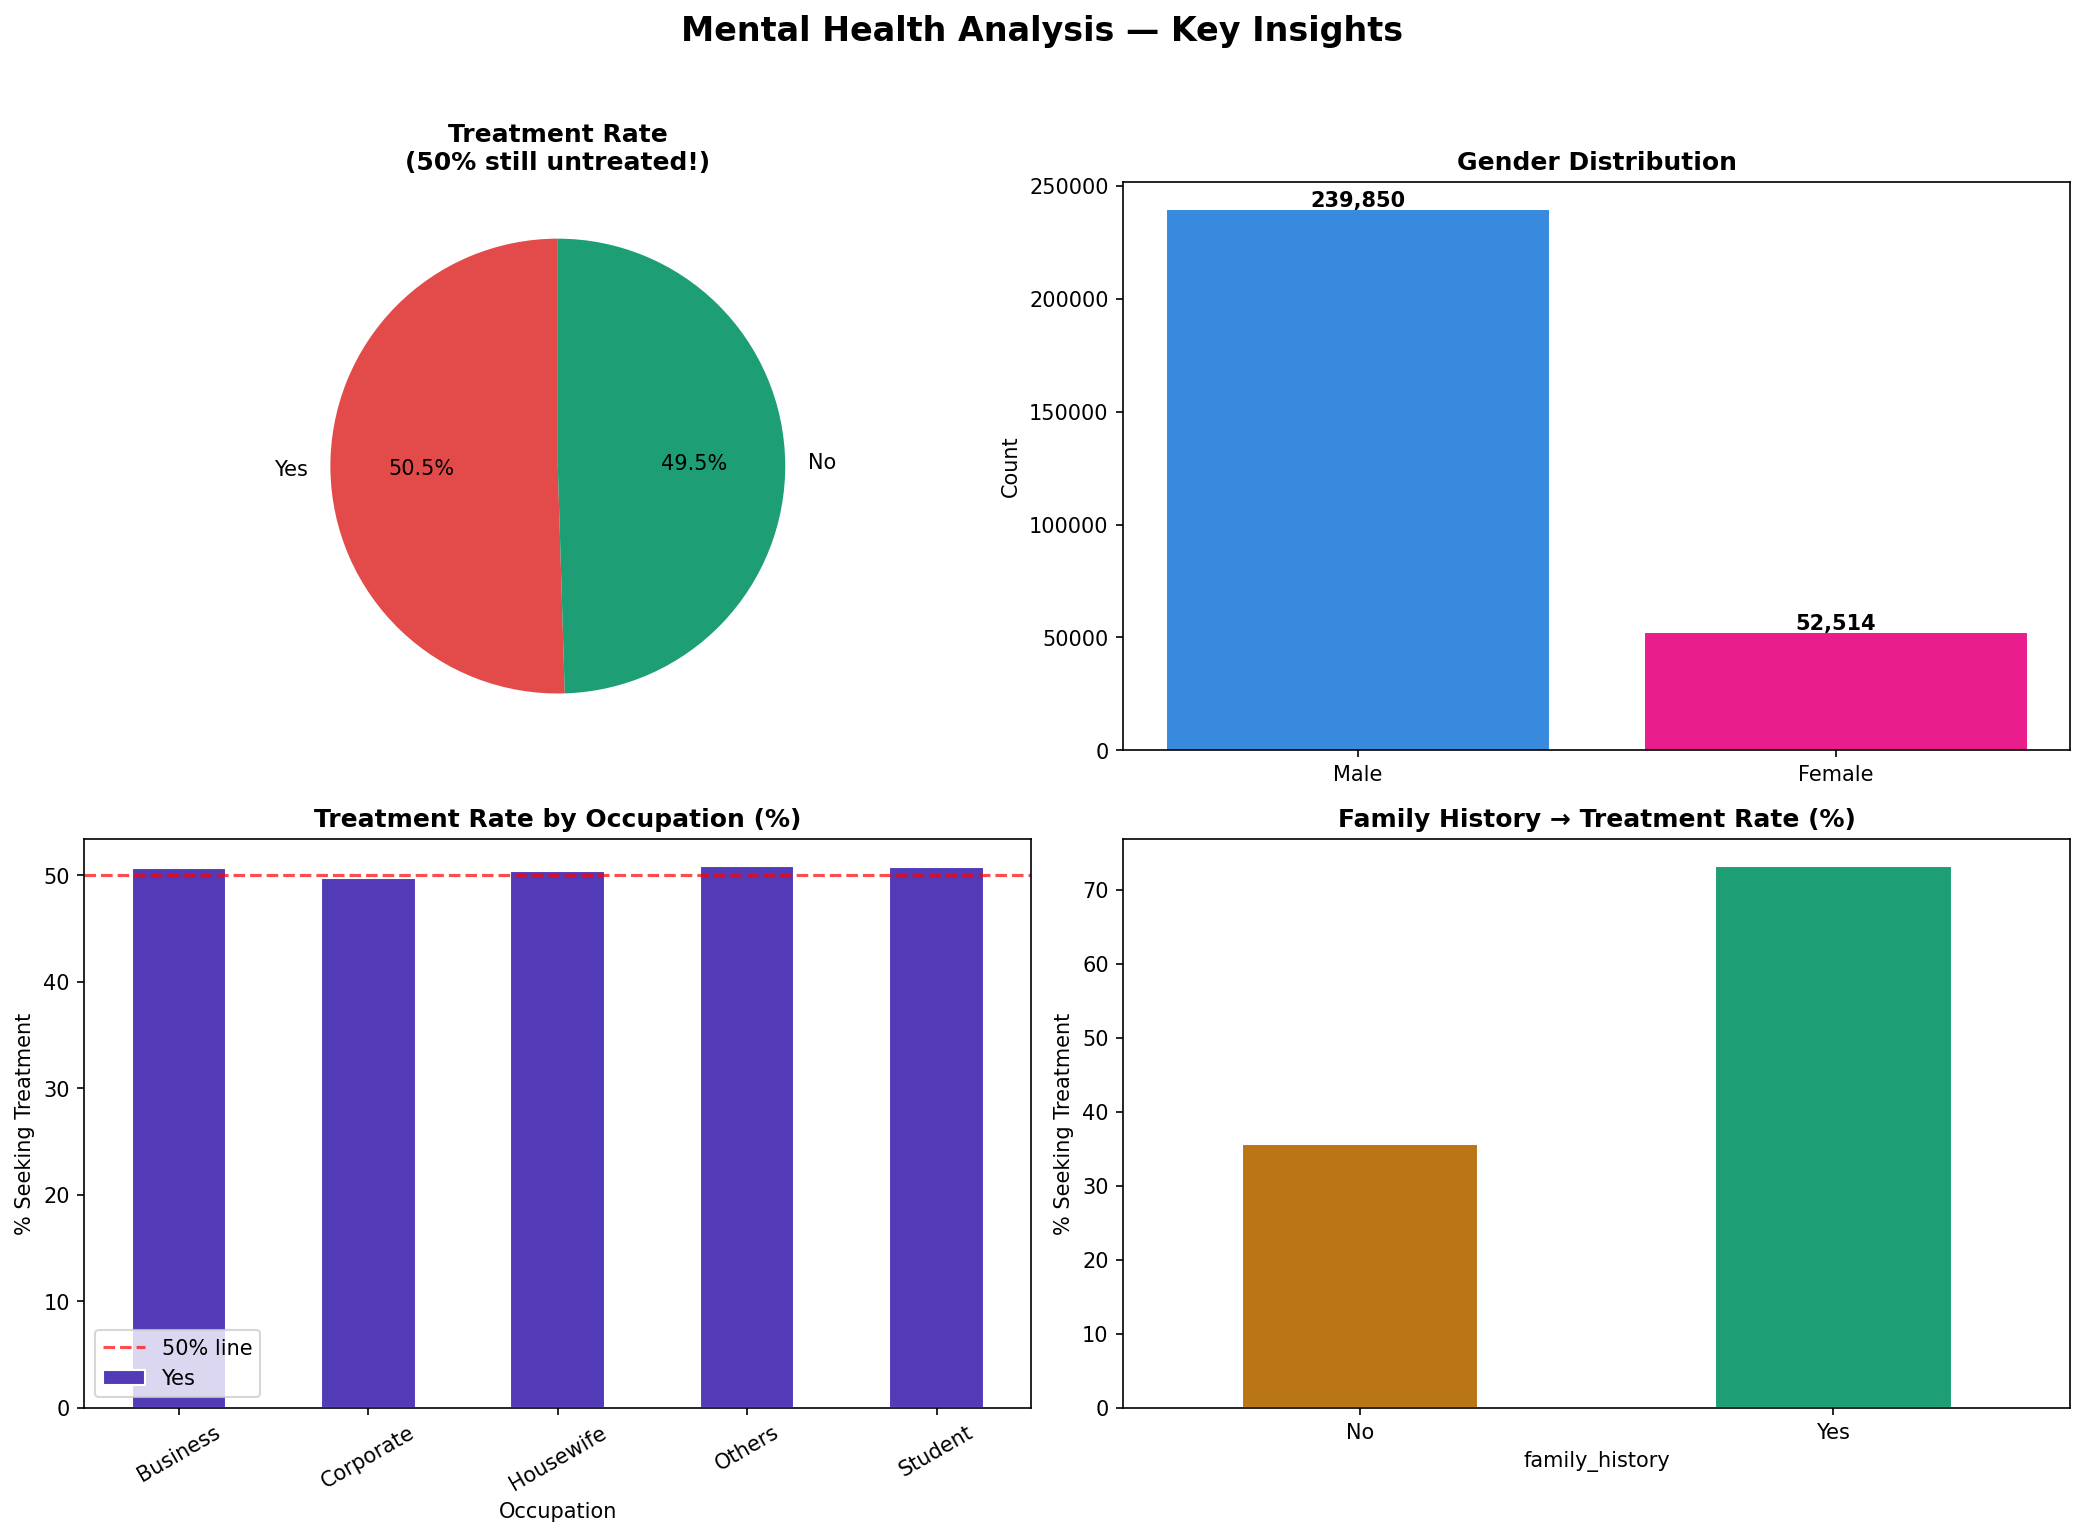

✅ Chart saved in visualizations folder!


In [5]:
# ============================================
# STEP 4: VISUALIZATIONS
# ============================================

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mental Health Analysis — Key Insights', 
             fontsize=16, fontweight='bold', y=1.02)

# Chart 1 — Treatment Rate
treatment_counts = df['treatment'].value_counts()
colors1 = ['#E24B4A', '#1D9E75']
axes[0,0].pie(treatment_counts.values, labels=treatment_counts.index,
              autopct='%1.1f%%', colors=colors1, startangle=90)
axes[0,0].set_title('Treatment Rate\n(50% still untreated!)', fontweight='bold')

# Chart 2 — Gender Distribution
gender_counts = df['Gender'].value_counts()
axes[0,1].bar(gender_counts.index, gender_counts.values, 
              color=['#378ADD', '#E91E8C'], edgecolor='white', linewidth=0.5)
axes[0,1].set_title('Gender Distribution', fontweight='bold')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0,1].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold', fontsize=10)

# Chart 3 — Occupation vs Treatment
occ_treatment = df.groupby('Occupation')['treatment'].value_counts(
    normalize=True).unstack() * 100
occ_treatment['Yes'].plot(kind='bar', ax=axes[1,0], 
                           color='#533AB7', edgecolor='white')
axes[1,0].set_title('Treatment Rate by Occupation (%)', fontweight='bold')
axes[1,0].set_ylabel('% Seeking Treatment')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% line')
axes[1,0].legend()

# Chart 4 — Family History Impact
family = df.groupby('family_history')['treatment'].value_counts(
    normalize=True).unstack() * 100
family['Yes'].plot(kind='bar', ax=axes[1,1], 
                   color=['#BA7517', '#1D9E75'], edgecolor='white')
axes[1,1].set_title('Family History → Treatment Rate (%)', fontweight='bold')
axes[1,1].set_ylabel('% Seeking Treatment')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../visualizations/mental_health_insights.png', 
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved in visualizations folder!")

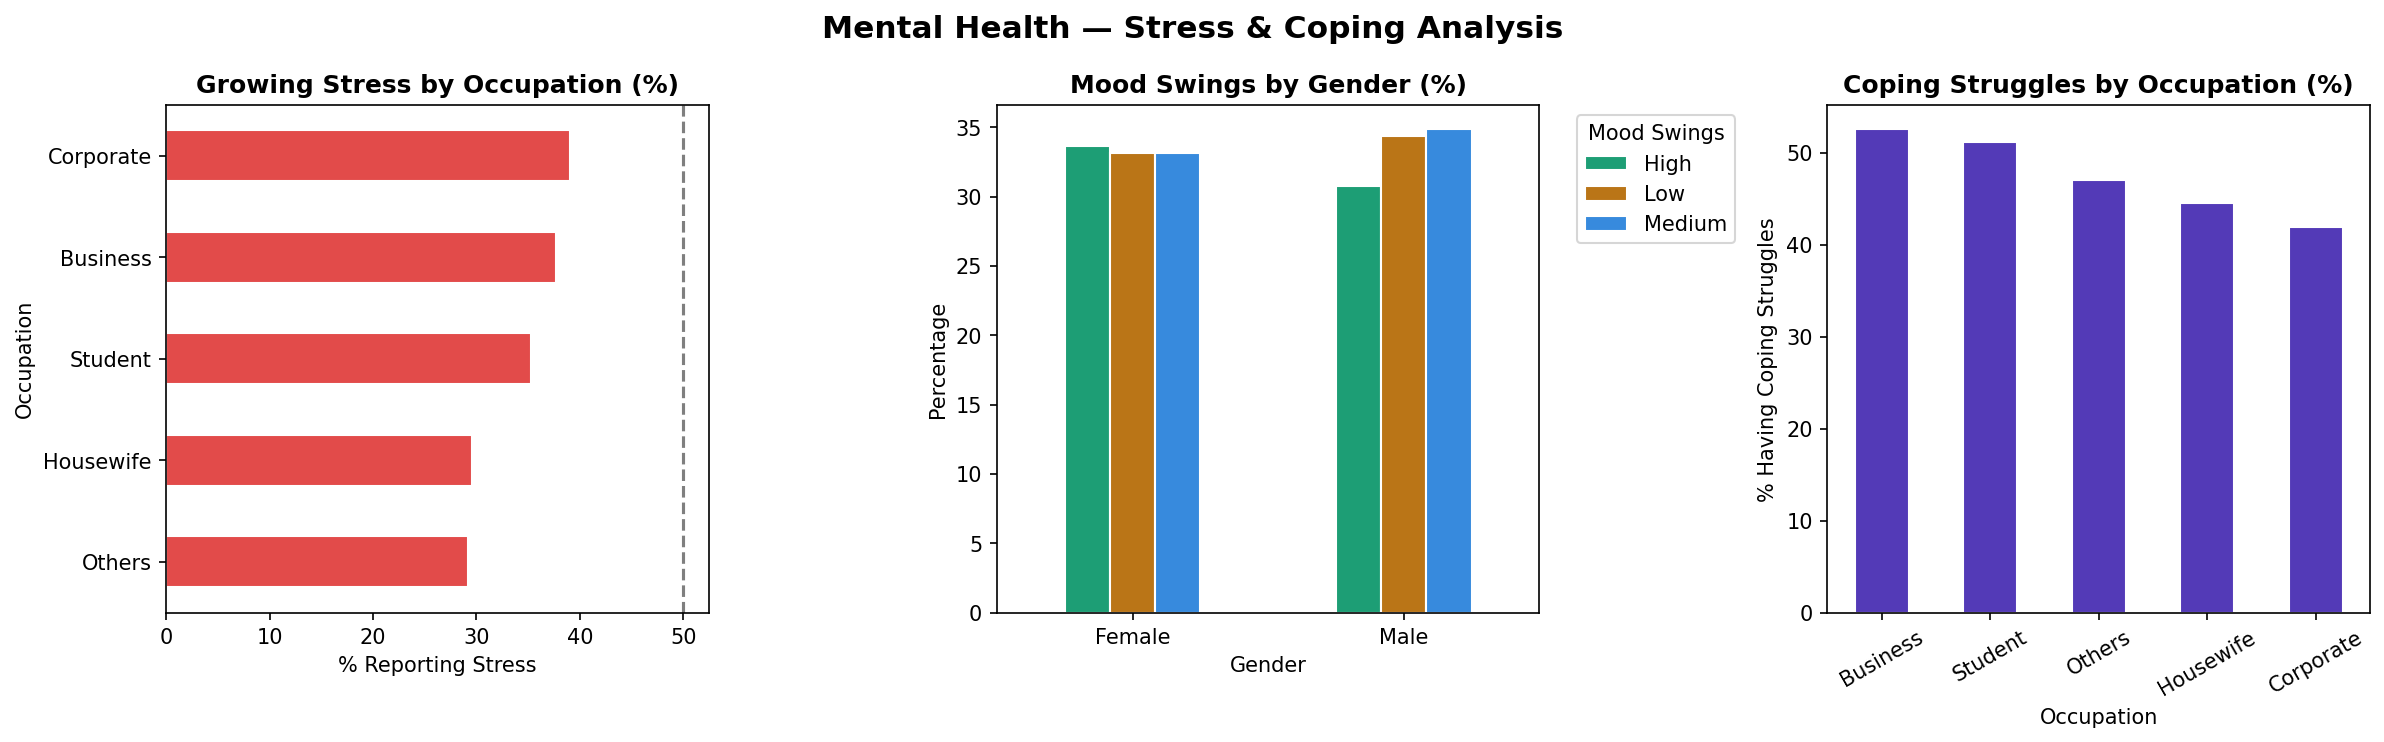

✅ Stress analysis chart saved!


In [6]:
# ============================================
# STEP 5: GROWING STRESS DEEP ANALYSIS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mental Health — Stress & Coping Analysis', 
             fontsize=15, fontweight='bold')

# Chart 1 — Growing Stress by Occupation
stress_occ = df.groupby('Occupation')['Growing_Stress'].value_counts(
    normalize=True).unstack() * 100
stress_occ['Yes'].sort_values(ascending=True).plot(
    kind='barh', ax=axes[0], color='#E24B4A', edgecolor='white')
axes[0].set_title('Growing Stress by Occupation (%)', fontweight='bold')
axes[0].set_xlabel('% Reporting Stress')
axes[0].axvline(x=50, color='black', linestyle='--', alpha=0.5)

# Chart 2 — Mood Swings by Gender
mood_gender = df.groupby('Gender')['Mood_Swings'].value_counts(
    normalize=True).unstack() * 100
mood_gender.plot(kind='bar', ax=axes[1], 
                 color=['#1D9E75', '#BA7517', '#378ADD'], 
                 edgecolor='white')
axes[1].set_title('Mood Swings by Gender (%)', fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Mood Swings', bbox_to_anchor=(1.05, 1))

# Chart 3 — Coping Struggles by Occupation
cope_occ = df.groupby('Occupation')['Coping_Struggles'].value_counts(
    normalize=True).unstack() * 100
cope_occ['Yes'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[2], color='#533AB7', edgecolor='white')
axes[2].set_title('Coping Struggles by Occupation (%)', fontweight='bold')
axes[2].set_ylabel('% Having Coping Struggles')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../visualizations/stress_analysis.png', 
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Stress analysis chart saved!")

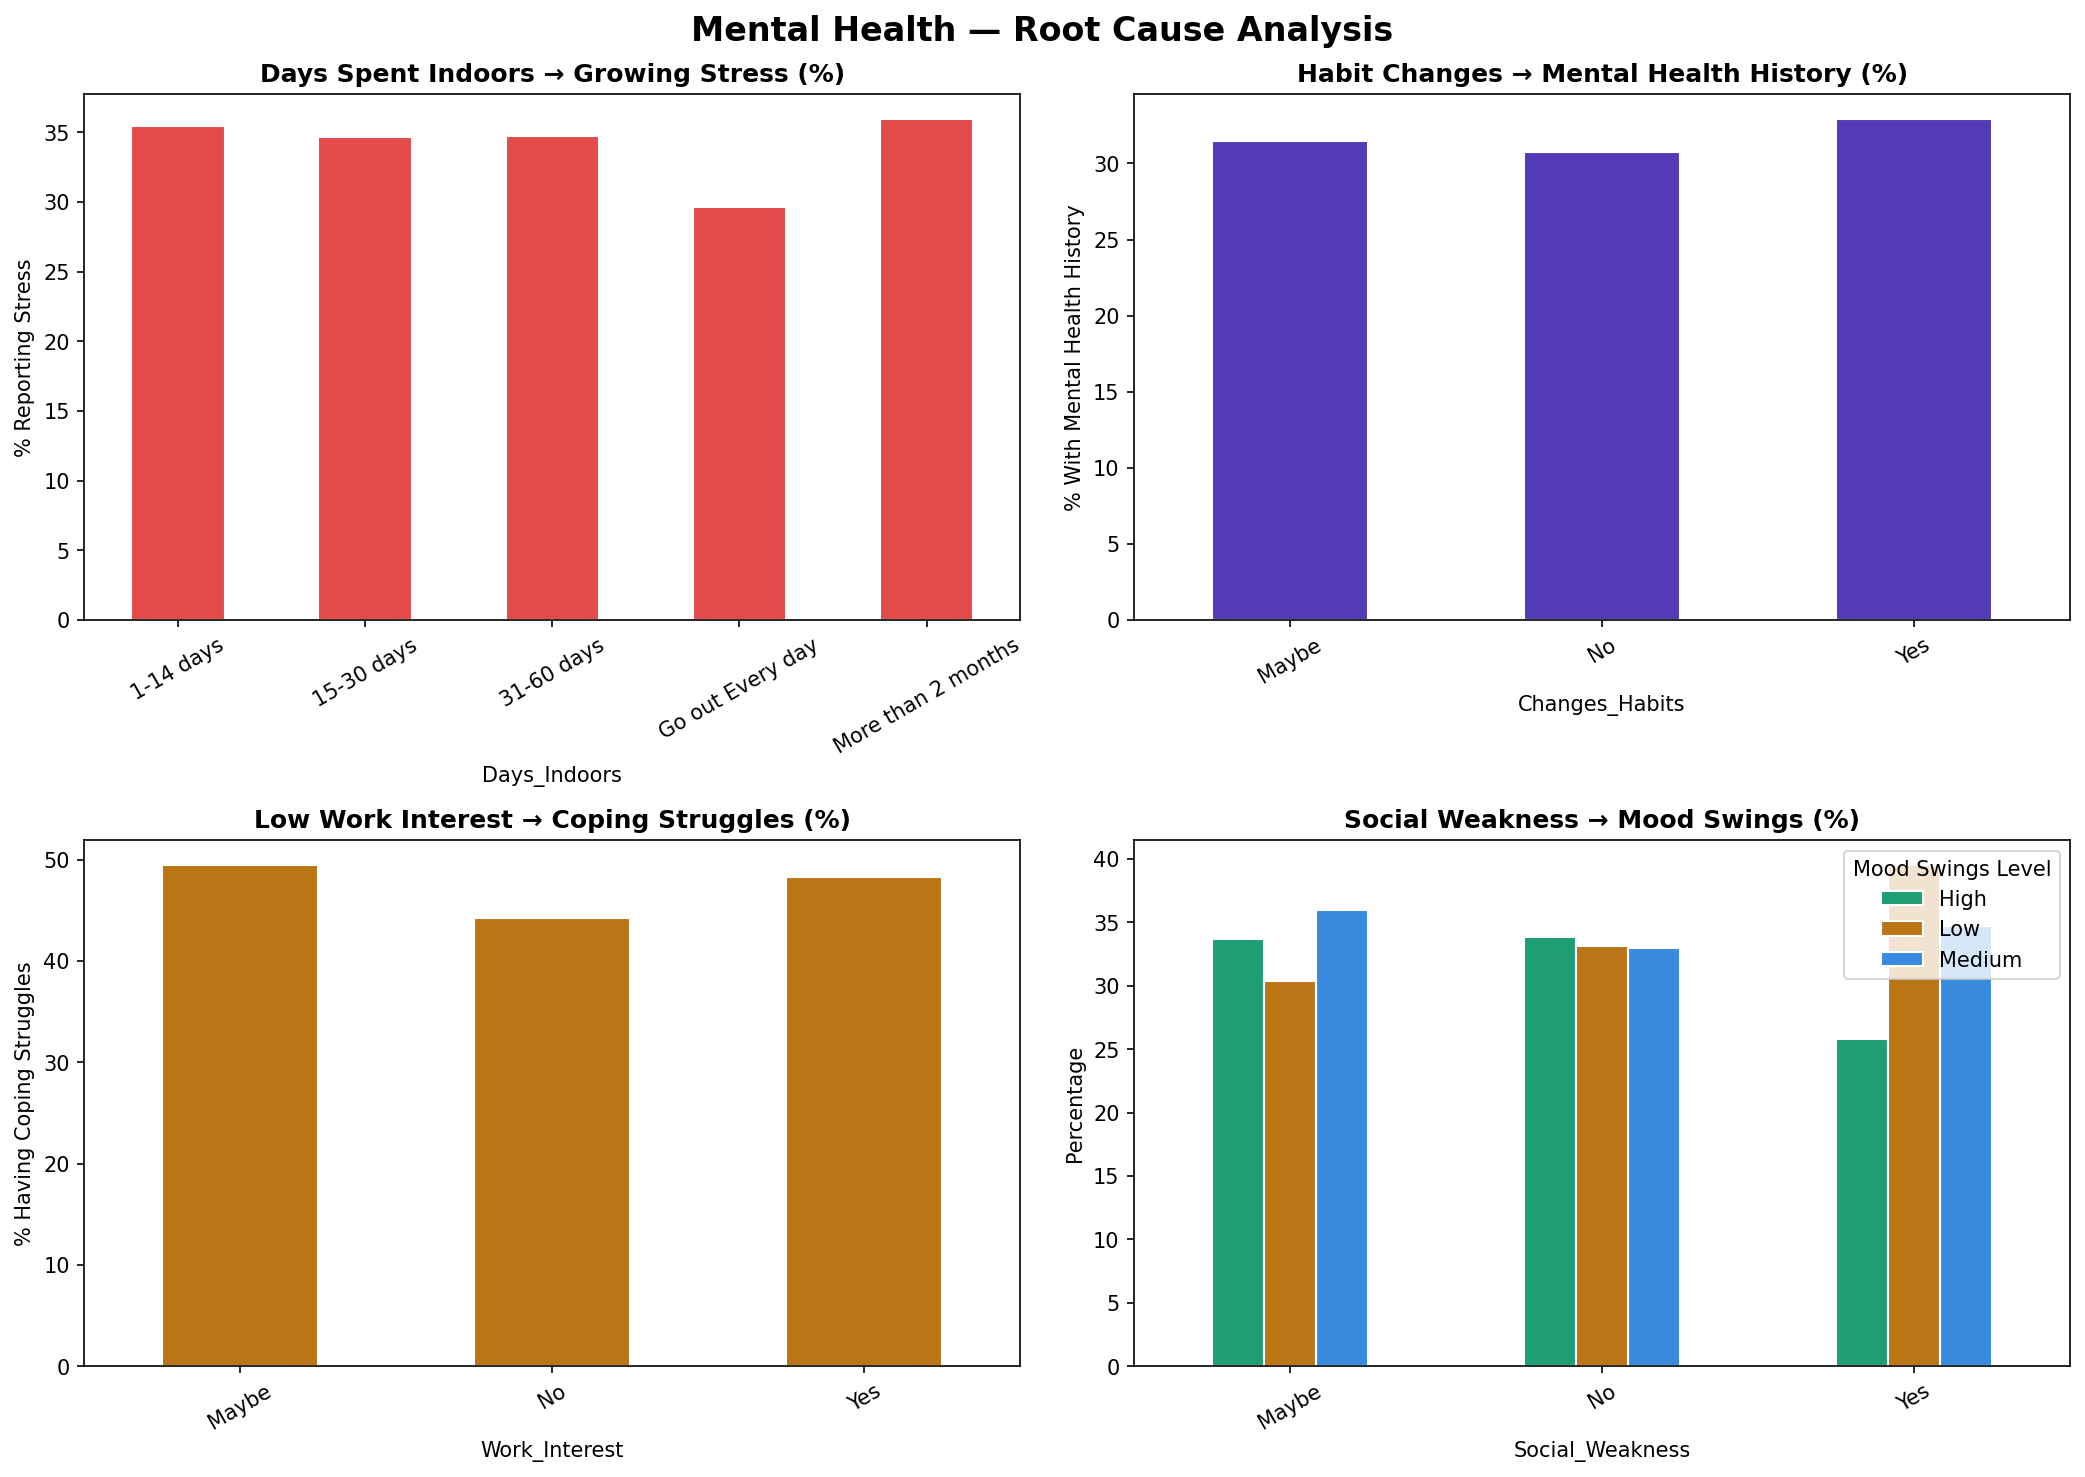

✅ Root cause analysis saved!


In [7]:
# ============================================
# STEP 6: ROOT CAUSE ANALYSIS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mental Health — Root Cause Analysis', 
             fontsize=16, fontweight='bold')

# Chart 1 — Days Indoors ka stress pe asar
stress_indoor = df.groupby('Days_Indoors')['Growing_Stress'].value_counts(
    normalize=True).unstack() * 100
stress_indoor['Yes'].plot(kind='bar', ax=axes[0,0], 
                          color='#E24B4A', edgecolor='white')
axes[0,0].set_title('Days Spent Indoors → Growing Stress (%)', fontweight='bold')
axes[0,0].set_ylabel('% Reporting Stress')
axes[0,0].tick_params(axis='x', rotation=30)

# Chart 2 — Changes in Habits ka mental health pe asar
habit_mental = df.groupby('Changes_Habits')['Mental_Health_History'].value_counts(
    normalize=True).unstack() * 100
habit_mental['Yes'].plot(kind='bar', ax=axes[0,1],
                         color='#533AB7', edgecolor='white')
axes[0,1].set_title('Habit Changes → Mental Health History (%)', fontweight='bold')
axes[0,1].set_ylabel('% With Mental Health History')
axes[0,1].tick_params(axis='x', rotation=30)

# Chart 3 — Work Interest vs Coping Struggles
work_cope = df.groupby('Work_Interest')['Coping_Struggles'].value_counts(
    normalize=True).unstack() * 100
work_cope['Yes'].plot(kind='bar', ax=axes[1,0],
                      color='#BA7517', edgecolor='white')
axes[1,0].set_title('Low Work Interest → Coping Struggles (%)', fontweight='bold')
axes[1,0].set_ylabel('% Having Coping Struggles')
axes[1,0].tick_params(axis='x', rotation=30)

# Chart 4 — Social Weakness vs Mood Swings
social_mood = df.groupby('Social_Weakness')['Mood_Swings'].value_counts(
    normalize=True).unstack() * 100
social_mood.plot(kind='bar', ax=axes[1,1],
                 color=['#1D9E75', '#BA7517', '#378ADD'],
                 edgecolor='white')
axes[1,1].set_title('Social Weakness → Mood Swings (%)', fontweight='bold')
axes[1,1].set_ylabel('Percentage')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(title='Mood Swings Level')

plt.tight_layout()
plt.savefig('../visualizations/root_cause_analysis.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Root cause analysis saved!")

In [8]:
pip install seaborn plotly


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.2 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.9 MB 1.4 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.9 MB 1.3 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.9 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.9 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.9 MB 1.2 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.9 MB 1.2 MB/s eta 0:00:07
   --------- ------------------------------ 2.4/9.9 MB 1.2 MB/s eta 0:00:07
   ----------- ---------------------------- 2.9/9.9


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cleaned_mental_health.csv')
print("✅ Data loaded! Shape:", df.shape)

✅ Data loaded! Shape: (292364, 17)
